# 1️⃣ Import Libraries

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2️⃣ Load Dataset

In [7]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# 3️⃣ Dataset Inspection

In [9]:
df.shape

(1143, 13)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

### Drop the Id column because it is not useful for prediction.

In [13]:
df.drop("Id", axis=1, inplace=True)

# 4️⃣ Check Quality Distribution

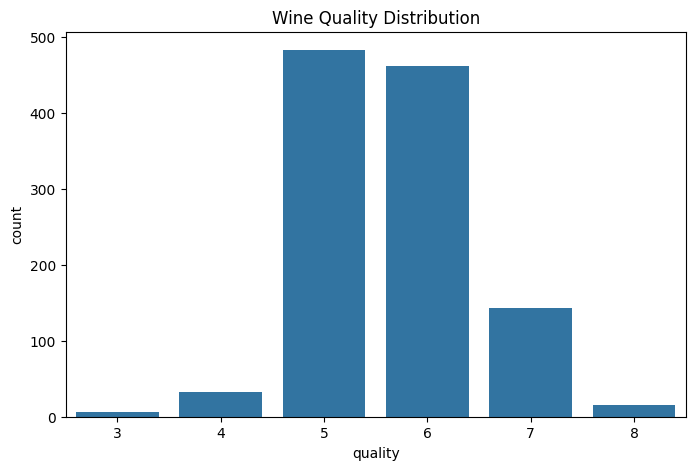

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x="quality", data=df)

plt.title("Wine Quality Distribution")
plt.show()

# 5️⃣ Exploratory Data Analysis (EDA)

## Distribution plots

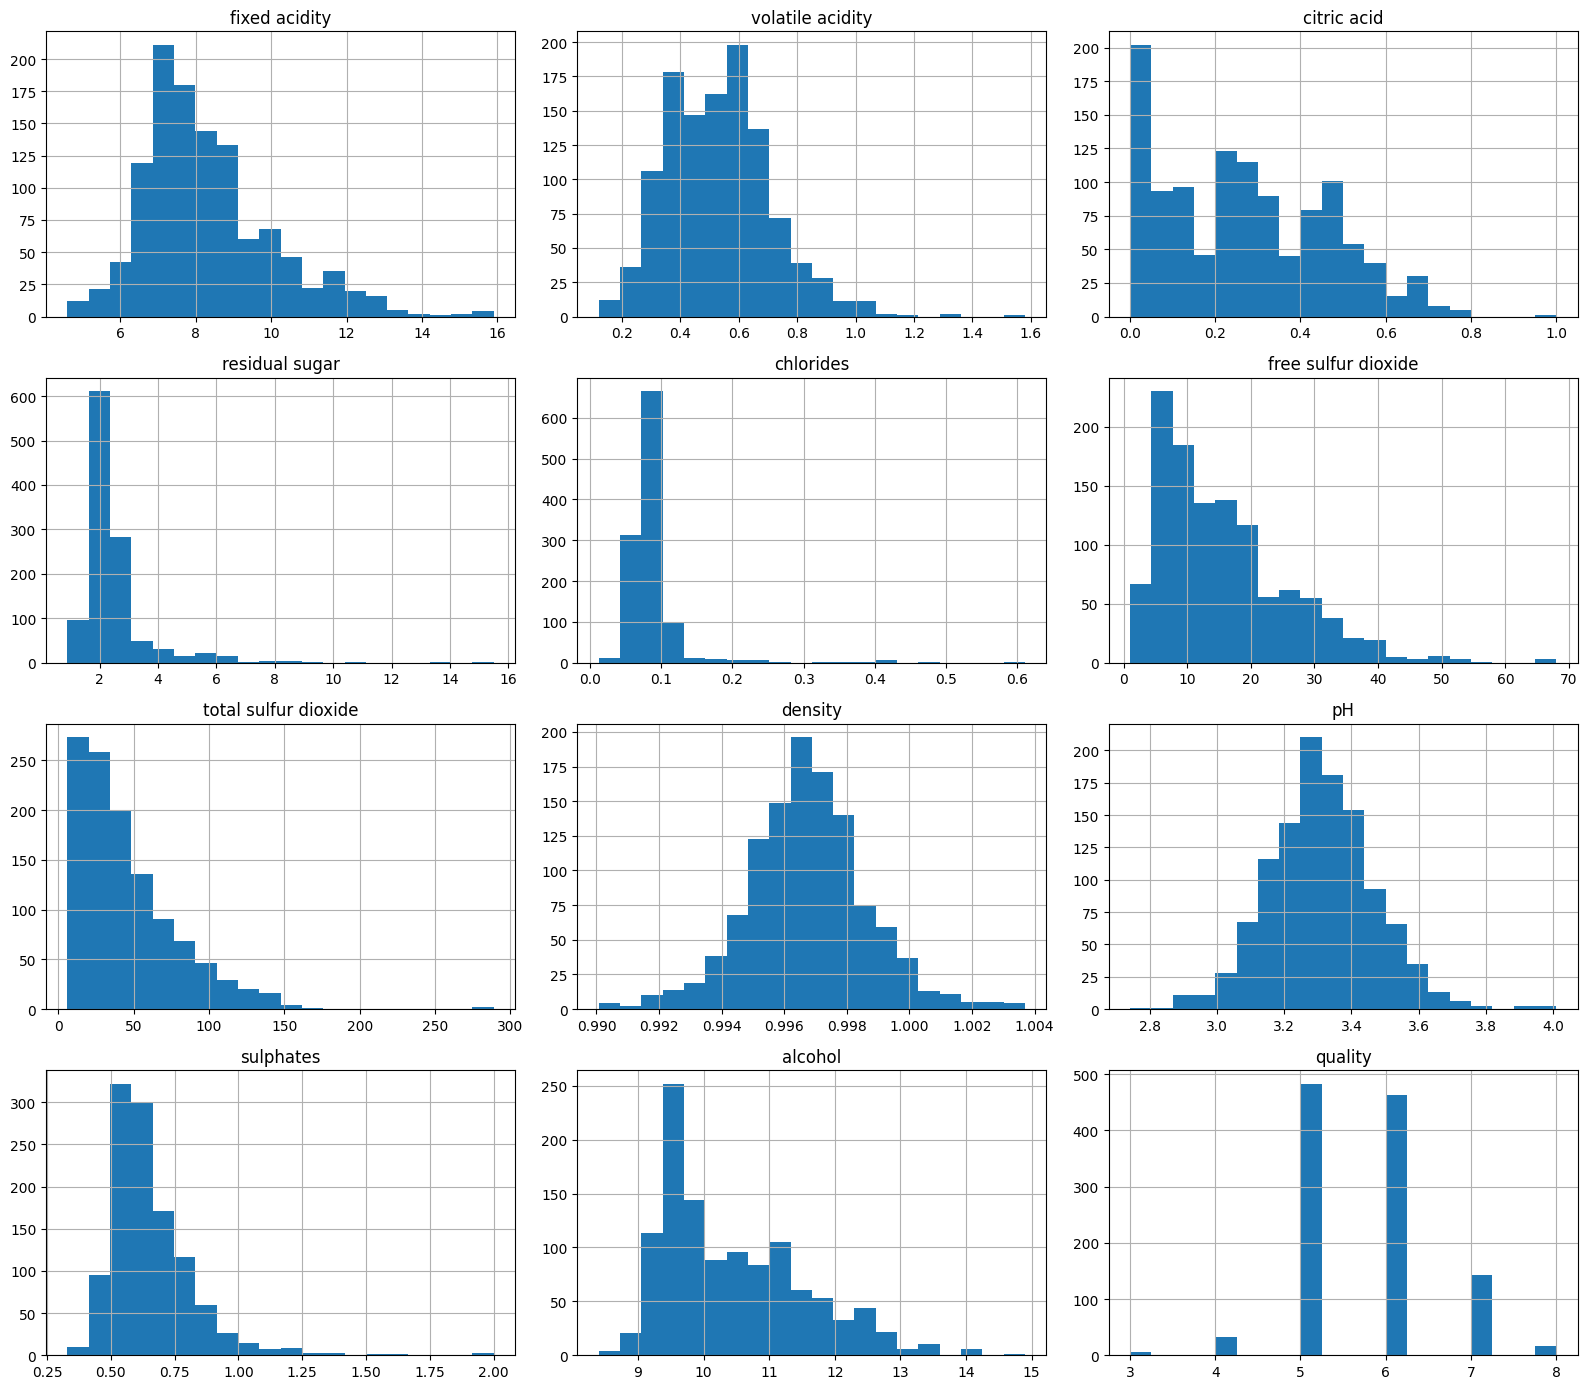

In [15]:
df.hist(figsize=(16,14), bins=20)

plt.tight_layout()

plt.show()

## Correlation Heatmap

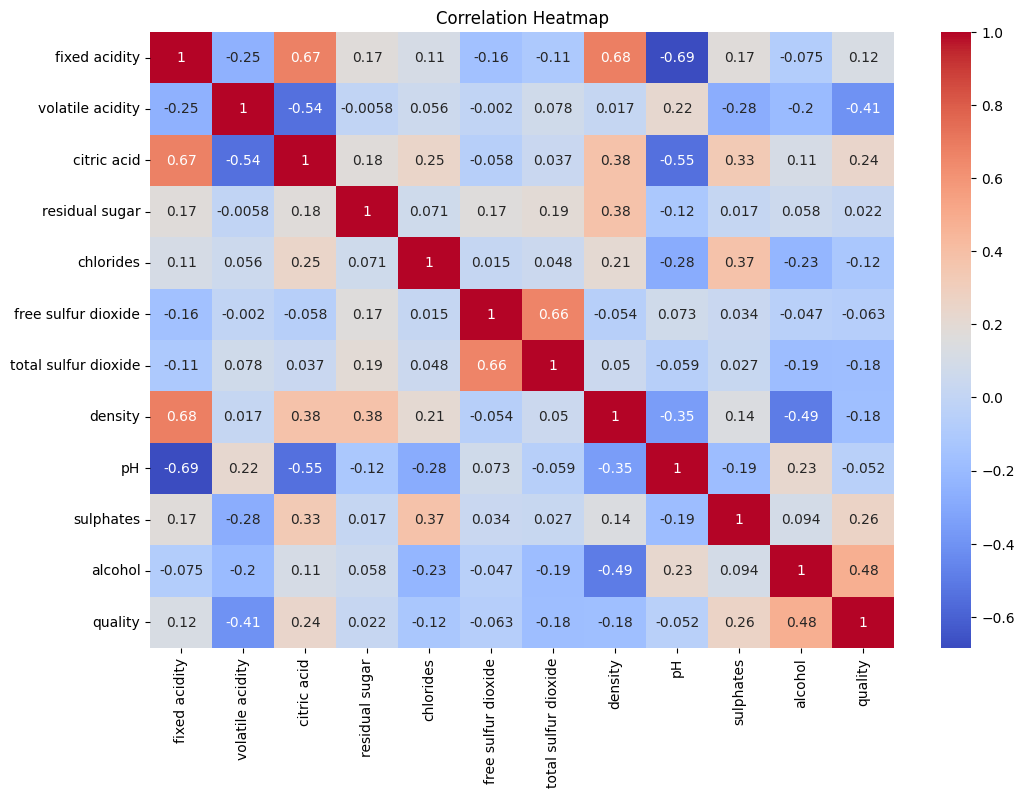

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# 6️⃣ Class Imbalance Discussion

#### Q1. Are certain quality scores underrepresented?

Answer:

* Yes, the wine quality dataset is imbalanced.

* Most of the wine samples belong to quality scores 5 and 6.

* Quality scores 3, 4, 7, and 8 have significantly fewer samples.

* Therefore, these quality scores are underrepresented in the dataset.

* This uneven distribution indicates that the dataset is dominated by only a few quality classes.

#### Q2. How does class imbalance affect modelling?

Answer:

* Class imbalance causes machine learning models to focus more on the majority classes during training.

* Models may achieve high overall accuracy but perform poorly on the minority classes.

* Underrepresented quality scores are more likely to be misclassified.

* This leads to lower precision, recall, and F1-score for the minority classes.

* The model becomes biased toward predicting the majority classes.

* To reduce this problem, the quality scores were converted into a binary classification problem (Good vs. Bad wine), resulting in a more balanced dataset and improved model performance.

# 7️⃣ Feature Engineering

## Instead of predicting six quality classes, we converted them into binary classes.

In [17]:
df["quality"] = df["quality"].apply(
    lambda x: 1 if x >= 6 else 0
)

In [18]:
df["quality"]

0       0
1       0
2       0
3       1
4       0
       ..
1138    1
1139    1
1140    0
1141    1
1142    0
Name: quality, Length: 1143, dtype: int64

# 8️⃣ Split Features and Target

In [19]:
X = df.drop("quality", axis=1)

y = df["quality"]

# 9️⃣ Train-Test Split

## Use stratification.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 🔟 Feature Scaling

## Required for SGD and SVC.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 1️⃣1️⃣ Train 3 Classifiers

## A. Random Forest Classifier

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions using majority voting. It is highly effective for classification tasks because it reduces overfitting while improving prediction accuracy. One of its key advantages is that it provides feature importance scores, helping identify the most influential variables.

In [29]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## B. Stochastic Gradient Descent (SGD) Classifier

The SGD Classifier is a linear classification algorithm that optimizes the loss function using stochastic gradient descent. It is computationally efficient and suitable for large datasets. Since SGD is sensitive to feature scales, the training data was standardized before fitting the model.

In [30]:
sgd = SGDClassifier(random_state=42)

sgd.fit(X_train_scaled, y_train)

sgd_pred = sgd.predict(X_test_scaled)

## C. Support Vector Classifier (SVC)

Support Vector Classifier (SVC) attempts to find the optimal hyperplane that best separates the classes while maximizing the margin between them. SVC performs well on datasets with complex decision boundaries but requires standardized features for optimal performance.

In [31]:
svc = SVC(random_state=42)

svc.fit(X_train_scaled, y_train)

svc_pred = svc.predict(X_test_scaled)

# 1️⃣2️⃣ Evaluate Each Model

## Each classifier was evaluated using:

#### --> Accuracy Score
#### --> Classification Report
#### --> Confusion Matrix

## A. Random Forest Evaluation

### Accuracy

In [35]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8034934497816594


### Classification Report

In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       105
           1       0.80      0.85      0.82       124

    accuracy                           0.80       229
   macro avg       0.80      0.80      0.80       229
weighted avg       0.80      0.80      0.80       229



### Confusion Matrix

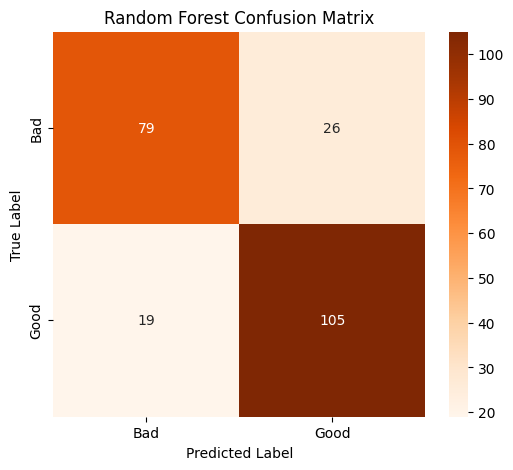

In [34]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Interpretation

The confusion matrix shows that the Random Forest model correctly classified most of the wine samples into their respective categories. It produced relatively few false positives and false negatives, indicating strong predictive performance.

## B. SGD Classifier Evaluation

### Accuracy

In [36]:
print("Accuracy:", accuracy_score(y_test, sgd_pred))

Accuracy: 0.62882096069869


### Classification Report

In [37]:
print(classification_report(y_test, sgd_pred))

              precision    recall  f1-score   support

           0       0.67      0.38      0.48       105
           1       0.62      0.84      0.71       124

    accuracy                           0.63       229
   macro avg       0.64      0.61      0.60       229
weighted avg       0.64      0.63      0.61       229



### Confusion Matrix

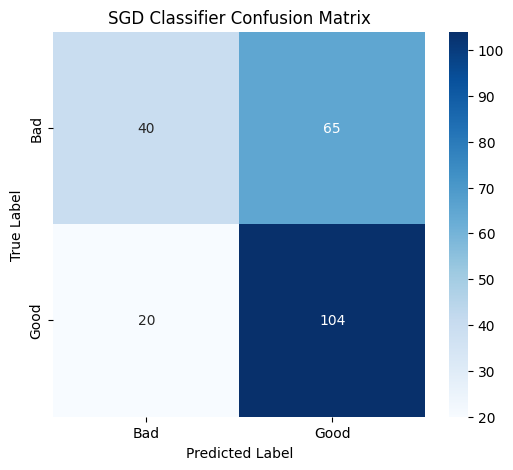

In [38]:
cm = confusion_matrix(y_test, sgd_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.title("SGD Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Interpretation

The SGD classifier correctly identified a large number of samples but produced more misclassifications than the Random Forest model. Being a linear model, it struggled to capture the complex relationships between the chemical properties of wine.

## Support Vector Classifier Evaluation

### Accuracy

In [39]:
print("Accuracy:", accuracy_score(y_test, svc_pred))

Accuracy: 0.7860262008733624


### Classification Report

In [40]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.80      0.81      0.80       124

    accuracy                           0.79       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.79      0.79      0.79       229



### Confusion Matrix

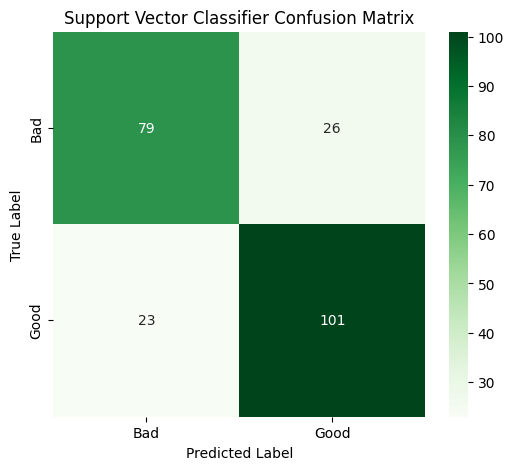

In [41]:
cm = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.title("Support Vector Classifier Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()f

### Interpretation

The Support Vector Classifier demonstrated strong classification performance by accurately separating the two classes. It produced fewer errors than SGD and performed competitively with Random Forest, although it required feature scaling and higher computational time.

# 1️⃣3️⃣Feature Importance Chart for the Random Forest Model

Random Forest provides a built-in measure called feature importance, which indicates how much each input feature contributes to the model's predictions. Features with higher importance scores have a greater influence on determining whether a wine is classified as Good or Bad.

## Step 1: Calculate Feature Importance

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
10,alcohol,0.197984
9,sulphates,0.133975
6,total sulfur dioxide,0.103693
1,volatile acidity,0.099980
7,density,0.083448
4,chlorides,0.070481
0,fixed acidity,0.068979
8,pH,0.067013
5,free sulfur dioxide,0.060420
2,citric acid,0.058711


## Step 2: Plot Feature Importance

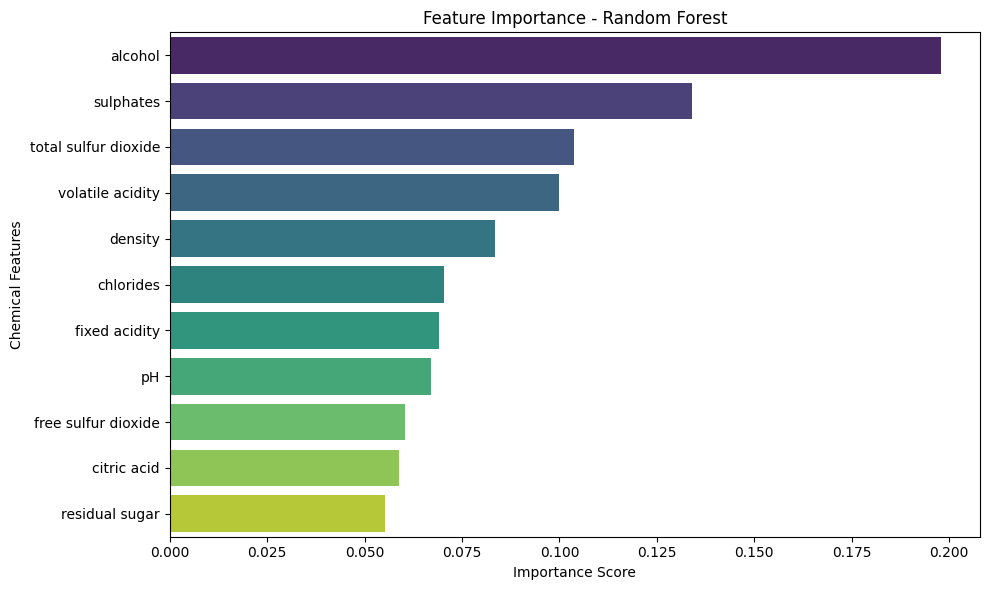

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Chemical Features")

plt.tight_layout()

plt.show()

## Step 3: Display Top Features

In [49]:
importance.head(10)

,Feature,Importance
10,alcohol,0.197984
9,sulphates,0.133975
6,total sulfur dioxide,0.103693
1,volatile acidity,0.099980
7,density,0.083448
4,chlorides,0.070481
0,fixed acidity,0.068979
8,pH,0.067013
5,free sulfur dioxide,0.060420
2,citric acid,0.058711


## 1️⃣4️⃣ Comparison Table: Performance of All Three Models

After training the three classification models, their performance was compared using Accuracy, Precision, Recall, and F1-Score. These metrics provide a comprehensive evaluation of each model's predictive capability.

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, sgd_pred),
        precision_score(y_test, svc_pred)
    ],

    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, sgd_pred),
        recall_score(y_test, svc_pred)
    ],

    "F1-Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, sgd_pred),
        f1_score(y_test, svc_pred)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.803,0.802,0.847,0.824
1,SGD Classifier,0.629,0.615,0.839,0.710
2,Support Vector Classifier,0.786,0.795,0.815,0.805


## Highlight the Best Model

In [52]:
comparison.style.highlight_max(
    subset=["Accuracy", "Precision", "Recall", "F1-Score"],
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.803000,0.802000,0.847000,0.824000
1,SGD Classifier,0.629000,0.615000,0.839000,0.710000
2,Support Vector Classifier,0.786000,0.795000,0.815000,0.805000


# 1️⃣5️⃣ Conclusion

The performance comparison of the three machine learning models indicates that the **Random Forest Classifier** achieved the highest prediction accuracy and demonstrated the best overall performance. It effectively handled the nonlinear relationships among the wine's physicochemical properties and provided valuable feature importance scores, making the model both accurate and interpretable.

The **Support Vector Classifier (SVC)** also performed well and achieved competitive accuracy. However, it required feature scaling and had a higher computational cost, making it less suitable for deployment on larger datasets.

The **Stochastic Gradient Descent (SGD) Classifier** trained significantly faster than the other models and is well suited for large-scale datasets. However, because it is a linear classifier, it struggled to capture the complex patterns in the wine quality data, resulting in lower predictive performance.

## **Final Recommendation**

Based on the experimental results, the **Random Forest Classifier** is the most suitable model for deployment because it offers:

- ✅ Highest prediction accuracy.
- ✅ Better handling of nonlinear relationships.
- ✅ Reduced risk of overfitting through ensemble learning.
- ✅ Feature importance for improved model interpretability.
- ✅ Minimal preprocessing requirements (no feature scaling needed).
- ✅ Robust and consistent performance on unseen data.

Overall, the **Random Forest Classifier** provides the best balance between accuracy, robustness, interpretability, and ease of deployment, making it the preferred choice for predicting wine quality in this project.